# Group Preprocessing Pipeline

**Module:** IT2011 - Artificial Intelligence and Machine Learning

**Dataset:** Medical Insurance Dataset

## Objective

This notebook integrates the preprocessing techniques completed by all six
group members into a single preprocessing pipeline.

## Preprocessing Flow

1. Missing Value and Duplicate Handling
2. Outlier Detection and Handling
3. Categorical Variable Encoding
4. Feature Engineering
5. Feature Selection
6. Train-Test Split and Feature Scaling

The original dataset is loaded once and each preprocessing technique is applied
sequentially.

The final processed dataset is saved in the results/outputs folder for later
machine learning model development.

## Import Required Libraries

The required Python libraries for data preprocessing, exploratory data analysis,
train-test splitting, and feature scaling are imported.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully.")

Libraries imported successfully.


## Load the Original Dataset

The original medical insurance dataset is loaded from the raw data folder.

The dataset is loaded only once. All preprocessing techniques are then applied
sequentially to the same dataset.

In [2]:
df = pd.read_csv("data/raw/insurance.csv")

print("Original Dataset Shape:", df.shape)

display(df.head())

Original Dataset Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Step 1 - Missing Value and Duplicate Handling

**Member 1:** IT25100065

## Selected Technique

Missing value detection/handling and duplicate removal.

## Explanation

Missing values represent incomplete observations and duplicate records represent
repeated observations.

Both can affect data quality and should be examined before further
preprocessing.

## Justification

The insurance dataset must first be checked for missing values and duplicate
records to ensure that the remaining preprocessing steps operate on clean data.

In [3]:
print("Missing Values Before Cleaning:")

print(df.isnull().sum())

print(
    "\nTotal Missing Values:",
    df.isnull().sum().sum()
)

Missing Values Before Cleaning:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total Missing Values: 0


In [4]:
if df.isnull().sum().sum() == 0:

    print("No missing values found.")
    print("No imputation was required.")

else:

    numeric_columns = df.select_dtypes(
        include="number"
    ).columns

    categorical_columns = df.select_dtypes(
        include="object"
    ).columns

    for column in numeric_columns:

        df[column] = df[column].fillna(
            df[column].median()
        )

    for column in categorical_columns:

        df[column] = df[column].fillna(
            df[column].mode()[0]
        )

    print("Missing values handled successfully.")

No missing values found.
No imputation was required.


In [5]:
duplicates_before = df.duplicated().sum()

print("Duplicates Before:", duplicates_before)

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicates After:", df.duplicated().sum())

print("Shape After Step 1:", df.shape)

Duplicates Before: 1
Duplicates After: 0
Shape After Step 1: (1337, 7)


# Step 2 - Outlier Detection and Handling

**Member 2:** IT25102316

## Selected Technique

Outlier detection and handling using the Interquartile Range (IQR).

## Explanation

The IQR method identifies observations that fall outside calculated lower and
upper boundaries.

## Justification

BMI is a continuous numerical feature and may contain extreme observations.

Potential BMI outliers are detected using IQR and capped at the calculated
boundaries instead of deleting complete customer records.

In [6]:
Q1 = df["bmi"].quantile(0.25)
Q3 = df["bmi"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 26.29
Q3: 34.7
IQR: 8.410000000000004
Lower Bound: 13.674999999999994
Upper Bound: 47.31500000000001


In [7]:
outlier_count = (
    (df["bmi"] < lower_bound) |
    (df["bmi"] > upper_bound)
).sum()

print(
    "BMI Outliers Before Handling:",
    outlier_count
)

BMI Outliers Before Handling: 9


In [8]:
df["bmi"] = df["bmi"].clip(
    lower=lower_bound,
    upper=upper_bound
)

remaining_outliers = (
    (df["bmi"] < lower_bound) |
    (df["bmi"] > upper_bound)
).sum()

print(
    "BMI Outliers After Handling:",
    remaining_outliers
)

print("Shape After Step 2:", df.shape)

BMI Outliers After Handling: 0
Shape After Step 2: (1337, 7)


# Step 3 - Categorical Variable Encoding

**Member 3:** IT25100060

## Selected Technique

One-Hot Encoding.

## Explanation

Categorical variables must be converted into numerical representations before
they can be used by many machine learning algorithms.

## Justification

The insurance dataset contains categorical variables such as sex, smoker, and
region.

One-Hot Encoding is used because these categories do not have a natural ordinal
relationship.

In [9]:
print("Categorical Columns Before Encoding:")

print(
    df.select_dtypes(
        include="object"
    ).columns.tolist()
)

Categorical Columns Before Encoding:
['sex', 'smoker', 'region']


C:\Users\USER\AppData\Local\Temp\ipykernel_17868\2400037506.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(


In [10]:
df = pd.get_dummies(
    df,
    columns=["sex", "smoker", "region"],
    drop_first=True,
    dtype=int
)

print("Shape After Step 3:", df.shape)

print("\nColumns After Encoding:")

print(df.columns.tolist())

display(df.head())

Shape After Step 3: (1337, 9)

Columns After Encoding:
['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


# Step 4 - Feature Engineering

**Member 4:** IT25102313

## Selected Technique

Feature engineering using an Age-BMI interaction feature.

## Explanation

Feature engineering creates new variables from existing features to represent
potential additional relationships in the dataset.

## Justification

Age and BMI may have a combined relationship with insurance charges.

Therefore, a new numerical interaction feature is created by multiplying age
and BMI.

In [11]:
df["age_bmi_interaction"] = (
    df["age"] * df["bmi"]
)

print(
    "Feature Created: age_bmi_interaction"
)

display(
    df[
        [
            "age",
            "bmi",
            "age_bmi_interaction",
            "charges"
        ]
    ].head()
)

print("Shape After Step 4:", df.shape)

Feature Created: age_bmi_interaction


,age,bmi,age_bmi_interaction,charges
0,19,27.900,530.100,16884.92400
1,18,33.770,607.860,1725.55230
2,28,33.000,924.000,4449.46200
3,33,22.705,749.265,21984.47061
4,32,28.880,924.160,3866.85520


Shape After Step 4: (1337, 10)


# Step 5 - Feature Selection

**Member 5:** IT25100050

## Selected Technique

Correlation-based feature selection.

## Explanation

Feature selection identifies predictor variables that may provide useful
information for predicting the target variable.

## Justification

After categorical encoding and feature engineering, all predictor variables are
available in numerical form.

Correlation analysis is used to examine their linear relationships with the
target variable, charges.

A simple absolute correlation threshold is used for exploratory feature
selection.

In [12]:
correlation_matrix = df.corr(
    numeric_only=True
)

target_correlation = (
    correlation_matrix["charges"]
    .drop("charges")
    .sort_values(
        key=abs,
        ascending=False
    )
)

print(
    "Feature Correlation with Charges:"
)

display(target_correlation)

Feature Correlation with Charges:


smoker_yes             0.787234
age_bmi_interaction    0.334156
age                    0.298308
bmi                    0.199063
region_southeast       0.073578
children               0.067389
sex_male               0.058044
region_southwest      -0.043637
region_northwest      -0.038695
Name: charges, dtype: float64

## Group Pipeline EDA

A correlation heatmap is used to visualize the relationships between the
preprocessed numerical features and insurance charges.

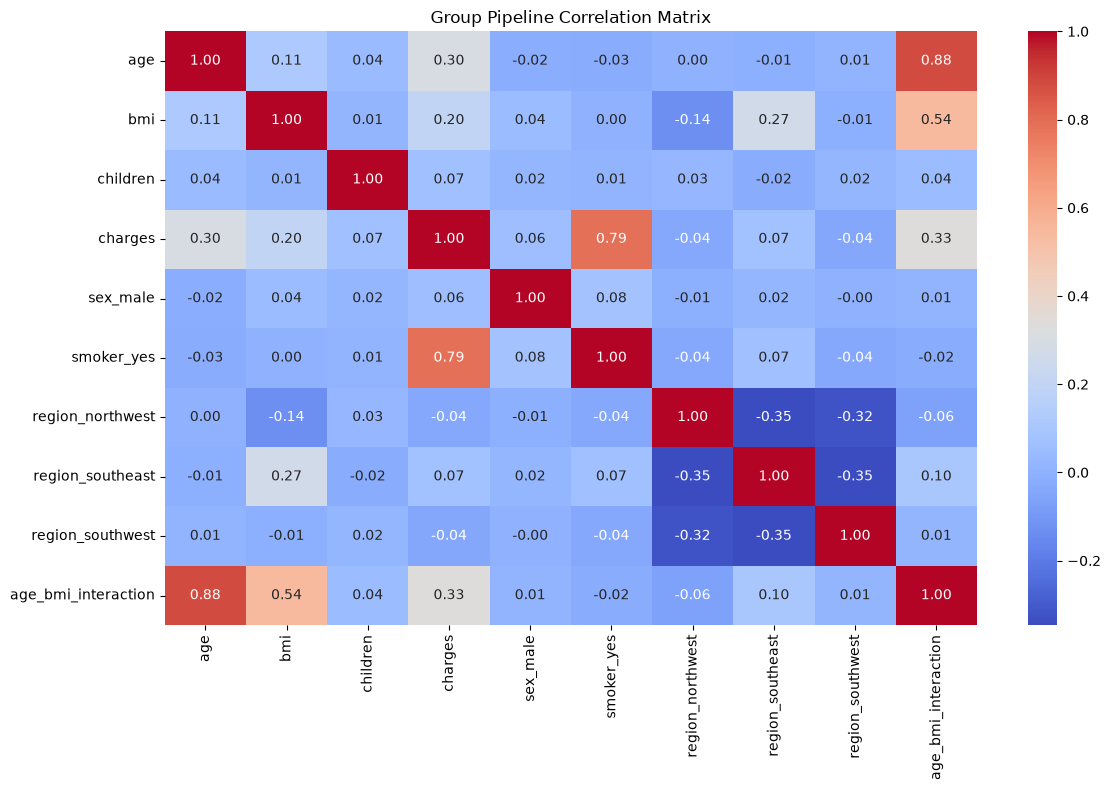

Group pipeline EDA visualization saved.


In [13]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Group Pipeline Correlation Matrix"
)

plt.tight_layout()

plt.savefig(
    "results/eda_visualizations/group_pipeline_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Group pipeline EDA visualization saved."
)

## Feature Selection

Features with an absolute correlation of 0.05 or greater with insurance charges
are selected.

The threshold is used as an exploratory rule. Low Pearson correlation does not
prove that a feature is completely useless because nonlinear relationships may
also exist.

In [14]:
threshold = 0.05

selected_features = target_correlation[
    target_correlation.abs() >= threshold
].index.tolist()

removed_features = target_correlation[
    target_correlation.abs() < threshold
].index.tolist()

print("Selected Features:")
print(selected_features)

print("\nFeatures Below Threshold:")
print(removed_features)

Selected Features:
['smoker_yes', 'age_bmi_interaction', 'age', 'bmi', 'region_southeast', 'children', 'sex_male']

Features Below Threshold:
['region_southwest', 'region_northwest']


In [15]:
df = df[
    selected_features + ["charges"]
].copy()

print(
    "Shape After Step 5:",
    df.shape
)

display(df.head())

Shape After Step 5: (1337, 8)


,smoker_yes,age_bmi_interaction,age,bmi,region_southeast,children,sex_male,charges
0,1,530.100,19,27.900,0,0,0,16884.92400
1,0,607.860,18,33.770,1,1,1,1725.55230
2,0,924.000,28,33.000,1,3,1,4449.46200
3,0,749.265,33,22.705,0,0,1,21984.47061
4,0,924.160,32,28.880,0,0,1,3866.85520


# Step 6 - Train-Test Split and Feature Scaling

**Member 6:** IT25102309

## Selected Technique

Feature standardization using StandardScaler.

## Explanation

StandardScaler transforms numerical features so that the training data has
approximately a mean of zero and a standard deviation of one.

## Justification

The selected predictor variables may have different numerical ranges.

The dataset is divided into training and testing sets before scaling. The scaler
is fitted only on the training data to prevent data leakage.

The same learned transformation is then applied to the testing data.

In [16]:
X = df.drop(
    "charges",
    axis=1
)

y = df["charges"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1337, 7)
Target Shape: (1337,)


## Train-Test Split

The dataset is divided into 80% training data and 20% testing data.

The split is performed before fitting StandardScaler to prevent information from
the testing dataset from influencing the training preprocessing process.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(
    "Training Set Shape:",
    X_train.shape
)

print(
    "Testing Set Shape:",
    X_test.shape
)

Training Set Shape: (1069, 7)
Testing Set Shape: (268, 7)


## Identify Features for Scaling

Binary indicator variables already use values 0 and 1.

Continuous numerical variables are identified separately and standardized using
StandardScaler.

In [18]:
binary_columns = [
    column
    for column in X_train.columns
    if set(
        X_train[column]
        .dropna()
        .unique()
    ).issubset({0, 1})
]

scale_columns = [
    column
    for column in X_train.columns
    if column not in binary_columns
]

print("Binary Columns:")
print(binary_columns)

print("\nColumns to Scale:")
print(scale_columns)

Binary Columns:
['smoker_yes', 'region_southeast', 'sex_male']

Columns to Scale:
['age_bmi_interaction', 'age', 'bmi', 'children']


## Apply StandardScaler

StandardScaler is fitted only on the continuous features in the training
dataset.

The training dataset is transformed using fit_transform, while the testing
dataset is transformed using the same fitted scaler with transform.

In [19]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_columns] = scaler.fit_transform(
    X_train[scale_columns]
)

X_test_scaled[scale_columns] = scaler.transform(
    X_test[scale_columns]
)

print(
    "Feature scaling completed successfully."
)

Feature scaling completed successfully.


## Verify Standardization

The standardized continuous features in the training dataset should have
approximately a mean of zero and a standard deviation of one.

In [20]:
print(
    "Training Mean After Scaling:"
)

print(
    X_train_scaled[scale_columns]
    .mean()
    .round(3)
)

print(
    "\nTraining Standard Deviation After Scaling:"
)

print(
    X_train_scaled[scale_columns]
    .std(ddof=0)
    .round(3)
)

Training Mean After Scaling:
age_bmi_interaction   -0.0
age                    0.0
bmi                   -0.0
children               0.0
dtype: float64

Training Standard Deviation After Scaling:
age_bmi_interaction    1.0
age                    1.0
bmi                    1.0
children               1.0
dtype: float64


# Final Processed Dataset

The preprocessing techniques contributed by all six group members have now been
integrated into a single sequential pipeline.

The processed training and testing datasets are saved separately so that the
same train-test split can be preserved during model development.

A combined processed dataset is also saved as the final preprocessing output.

In [21]:
train_processed = X_train_scaled.copy()
train_processed["charges"] = y_train

test_processed = X_test_scaled.copy()
test_processed["charges"] = y_test

In [22]:
train_processed.to_csv(
    "results/outputs/insurance_train_processed.csv",
    index=False
)

test_processed.to_csv(
    "results/outputs/insurance_test_processed.csv",
    index=False
)

print(
    "Training and testing datasets saved successfully."
)

Training and testing datasets saved successfully.


In [23]:
final_processed = pd.concat(
    [
        train_processed,
        test_processed
    ],
    axis=0
).sort_index()

final_processed.to_csv(
    "results/outputs/insurance_processed.csv",
    index=False
)

print(
    "Final processed dataset saved successfully."
)

print(
    "Final Processed Shape:",
    final_processed.shape
)

display(final_processed.head())

Final processed dataset saved successfully.
Final Processed Shape: (1337, 8)


,smoker_yes,age_bmi_interaction,age,bmi,region_southeast,children,sex_male,charges
0,1,-1.302916,-1.443557,-0.437481,0,-0.907908,0,16884.92400
1,0,-1.153262,-1.515026,0.540820,1,-0.070502,1,1725.55230
2,0,-0.544828,-0.800334,0.412491,1,1.604310,1,4449.46200
3,0,-0.881118,-0.442989,-1.303285,0,-0.907908,1,21984.47061
4,0,-0.544520,-0.514458,-0.274153,0,-0.907908,1,3866.85520


# Conclusion

The complete preprocessing pipeline successfully integrates the contributions
of all six group members.

The following preprocessing techniques were applied sequentially:

1. Missing value detection/handling and duplicate removal
2. Outlier detection and handling using IQR
3. Categorical variable encoding using One-Hot Encoding
4. Feature engineering using an Age-BMI interaction feature
5. Correlation-based feature selection
6. Train-test splitting and feature standardization

The final processed training and testing datasets are stored in the
results/outputs folder and can be used during the machine learning model
development stage.

The original dataset remains unchanged in the data/raw folder.